<a href="https://colab.research.google.com/github/Arijeet-Talukder/Python/blob/main/Copy_of_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from IPython.display import Markdown

file_id = "1AHmUq9hqZeXUBHm3RuVuKGZ0qGZQhm6f"

Markdown(f"[📄 Open PDF](https://drive.google.com/file/d/{file_id}/view)")

[📄 Open PDF](https://drive.google.com/file/d/1AHmUq9hqZeXUBHm3RuVuKGZ0qGZQhm6f/view)

In [ ]:
url = "https://raw.githubusercontent.com/abrshahed/data/refs/heads/main/DiaBD_A%20Diabetes%20Dataset%20for%20Enhanced%20Risk%20Analysis%20and%20Research%20in%20Bangladesh.csv"
df = pd.read_csv(url)
df.head()

,age,gender,pulse_rate,systolic_bp,diastolic_bp,glucose,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diabetic
0,42,Female,66,110,73,5.88,1.65,70.2,25.75,0,0,0,0,0,No
1,35,Female,60,125,68,5.71,1.47,42.5,19.58,0,0,0,0,0,No
2,62,Female,57,127,74,6.85,1.52,47.0,20.24,0,0,0,0,0,No
3,73,Male,55,193,112,6.28,1.63,57.4,21.72,0,0,0,0,0,No
4,68,Female,71,150,81,5.71,1.42,36.0,17.79,0,0,0,0,0,No


In [ ]:
df.shape

(5288, 15)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5288 entries, 0 to 5287
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     5288 non-null   int64  
 1   gender                  5288 non-null   object 
 2   pulse_rate              5288 non-null   int64  
 3   systolic_bp             5288 non-null   int64  
 4   diastolic_bp            5288 non-null   int64  
 5   glucose                 5288 non-null   float64
 6   height                  5288 non-null   float64
 7   weight                  5288 non-null   float64
 8   bmi                     5288 non-null   float64
 9   family_diabetes         5288 non-null   int64  
 10  hypertensive            5288 non-null   int64  
 11  family_hypertension     5288 non-null   int64  
 12  cardiovascular_disease  5288 non-null   int64  
 13  stroke                  5288 non-null   int64  
 14  diabetic                5288 non-null   

In [ ]:
df.describe()

,age,pulse_rate,systolic_bp,diastolic_bp,glucose,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke
count,5288.000000,5288.000000,5288.000000,5288.000000,5288.000000,5288.000000,5288.000000,5288.000000,5288.000000,5288.000000,5288.000000,5288.000000,5288.000000
mean,45.745651,76.626135,133.996596,82.229576,7.563922,1.548886,53.644100,22.466581,0.031959,0.111006,0.033661,0.011346,0.003782
std,13.422024,12.229319,22.231752,12.479007,2.944381,0.080328,10.076059,8.819898,0.175908,0.314169,0.180372,0.105924,0.061389
min,21.000000,5.000000,62.000000,45.000000,0.000000,0.360000,3.000000,1.220000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,35.000000,69.000000,119.000000,73.000000,6.000000,1.520000,46.775000,19.620000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,45.000000,76.000000,130.000000,81.000000,6.930000,1.550000,53.000000,21.870000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,55.000000,84.000000,147.000000,90.000000,8.130000,1.600000,59.900000,24.472500,0.000000,0.000000,0.000000,0.000000,0.000000
max,80.000000,133.000000,231.000000,119.000000,33.460000,1.960000,100.700000,574.130000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
df = df.drop_duplicates()

In [ ]:
df = df.fillna(df.mean(numeric_only=True))

In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
# Age Group
bins = [0, 30, 50, 100]
labels = ['Young', 'Adult', 'Senior']
df['AgeGroup'] = pd.cut(df['age'], bins=bins, labels=labels)

In [ ]:
def bmi_category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25:
        return 'Normal'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

df['BMICategory'] = df['bmi'].apply(bmi_category)

In [ ]:
# Average bmi of people by gender
avg_bmi_by_gender = df.groupby('gender')['bmi'].mean().sort_values(ascending=False)
print(avg_bmi_by_gender)

gender
Female    22.599656
Male      22.141517
Name: bmi, dtype: float64


In [ ]:
#z score
cols = ['glucose', 'bmi', 'age']
z_scores = (df[cols] - df[cols].mean()) / df[cols].std()

z = (
    0.5 * z_scores['glucose'] +
    0.3 * z_scores['bmi'] +
    0.2 * z_scores['age'] )

df['RiskIndex'] = 1 / (1 + np.exp(-z))

df['RiskIndex'] = df['RiskIndex'] * 100

In [ ]:
#Cap Outlier
for col in ['glucose', 'bmi', 'age']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.clip(df[col], lower, upper)

In [ ]:
df['diabetic'] = df['diabetic'].map({'Yes': 1, 'No': 0})

In [ ]:
age_group_analysis = df.groupby('AgeGroup', observed=True)['diabetic'].mean() * 100

print(age_group_analysis.round(2).astype(str) + '%')

AgeGroup
Young     2.08%
Adult     5.79%
Senior    9.55%
Name: diabetic, dtype: object


In [ ]:
bmi_group_analysis = df.groupby('BMICategory', observed=True)['diabetic'].mean() * 100
print(bmi_group_analysis.round(2).astype(str) + '%')

BMICategory
Normal          5.89%
Obese           9.96%
Overweight     10.98%
Underweight      3.0%
Name: diabetic, dtype: object


In [ ]:
corr = df[['glucose', 'bmi', 'age', 'diabetic']].corr()
weights = abs(corr['diabetic'].drop('diabetic'))

# normalize to sum = 1
weights = weights / weights.sum()
print(weights)
print(corr)

glucose    0.562751
bmi        0.230568
age        0.206681
Name: diabetic, dtype: float64
           glucose       bmi       age  diabetic
glucose   1.000000  0.057495  0.118353  0.245527
bmi       0.057495  1.000000 -0.174933  0.100597
age       0.118353 -0.174933  1.000000  0.090175
diabetic  0.245527  0.100597  0.090175  1.000000


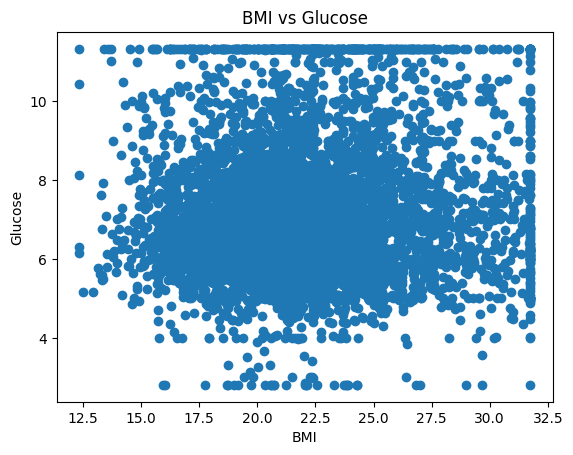

In [ ]:
#BMI vs Glucose
plt.figure()
plt.scatter(df['bmi'], df['glucose'])
plt.title('BMI vs Glucose')
plt.xlabel('BMI')
plt.ylabel('Glucose')
plt.show()

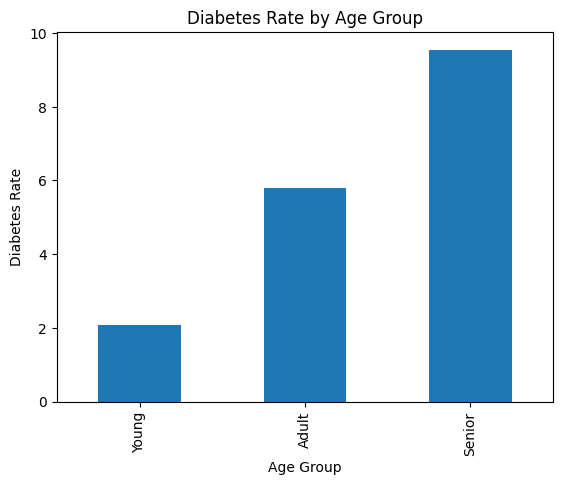

In [ ]:
#Diabetes by age group
plt.figure()
age_group_analysis.plot(kind='bar')
plt.title('Diabetes Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Diabetes Rate')
plt.show()

In [ ]:
print(df.groupby('diabetic')['RiskIndex'].mean())

diabetic
0    48.421635
1    63.851138
Name: RiskIndex, dtype: float64


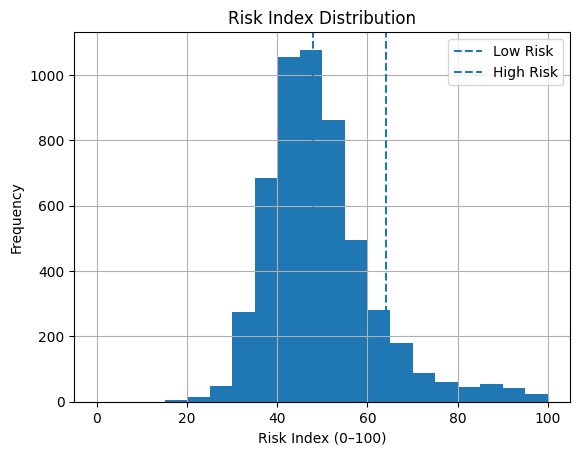

In [ ]:
#Histogram (Risk Index)
plt.figure()
plt.hist(df['RiskIndex'], bins=20, range=(0, 100))

plt.axvline(48, linestyle='--', label='Low Risk')
plt.axvline(64, linestyle='--', label='High Risk')

plt.title('Risk Index Distribution')
plt.xlabel('Risk Index (0–100)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
threshold = 64

df['Predicted'] = (df['RiskIndex'] >= threshold).astype(int)

wrong_predictions = (df['Predicted'] != df['diabetic']).sum()
correct_predictions = (df['Predicted'] == df['diabetic']).sum()

print("Correct predictions:", correct_predictions)
print("Wrong predictions:", wrong_predictions)

Correct predictions: 4719
Wrong predictions: 569


In [ ]:
accuracy = correct_predictions / len(df)
print("Accuracy:", accuracy * 100, "%")

Accuracy: 89.23978819969743 %


<Figure size 640x480 with 0 Axes>

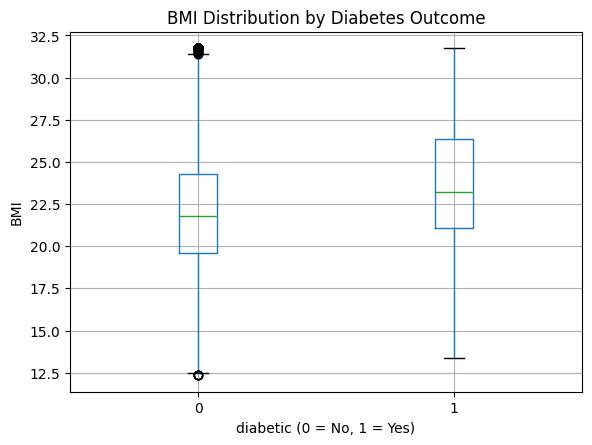

In [ ]:
#Box Plot(BMI vs diabetic)
plt.figure()
df.boxplot(column='bmi', by='diabetic')
plt.title('BMI Distribution by Diabetes Outcome')
plt.suptitle('')
plt.xlabel('diabetic (0 = No, 1 = Yes)')
plt.ylabel('BMI')
plt.show()

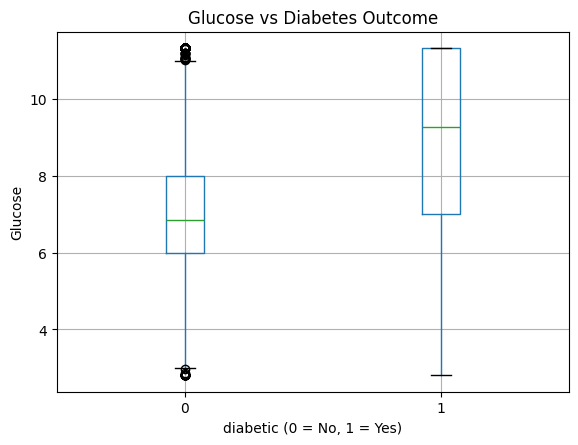

In [ ]:
df.boxplot(column='glucose', by='diabetic')
plt.title("Glucose vs Diabetes Outcome")
plt.suptitle('')
plt.xlabel('diabetic (0 = No, 1 = Yes)')
plt.ylabel('Glucose')
plt.show()

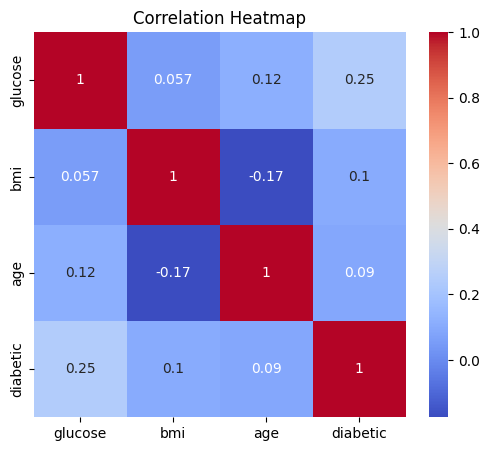

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

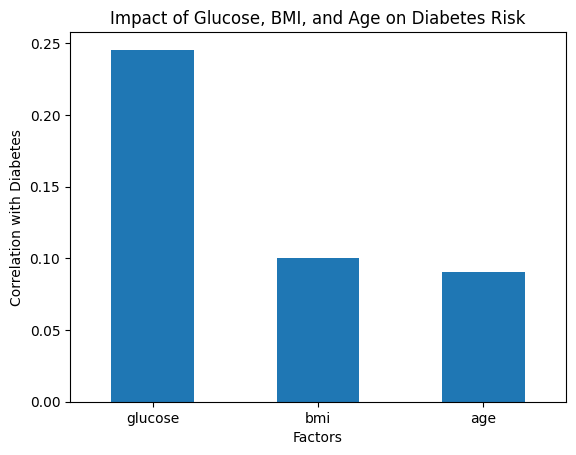

In [ ]:
focus = ['glucose', 'bmi', 'age']

correlation = df[focus + ['diabetic']].corr()['diabetic'].drop('diabetic')

plt.figure()
correlation.plot(kind='bar')

plt.title('Impact of Glucose, BMI, and Age on Diabetes Risk')
plt.xlabel('Factors')
plt.ylabel('Correlation with Diabetes')
plt.xticks(rotation=0)

plt.show()

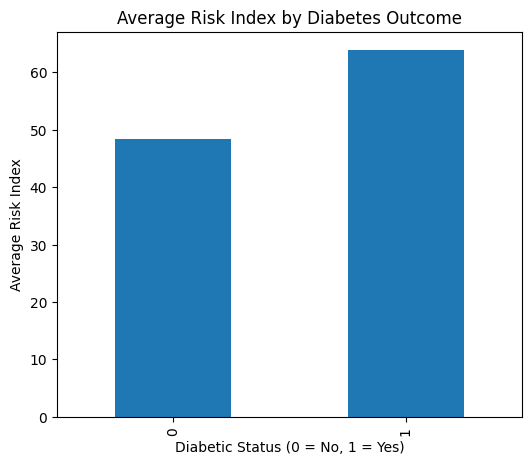

In [ ]:
avg_risk = df.groupby('diabetic')['RiskIndex'].mean()

plt.figure(figsize=(6,5))
avg_risk.plot(kind='bar')

plt.title('Average Risk Index by Diabetes Outcome')
plt.xlabel('Diabetic Status (0 = No, 1 = Yes)')
plt.ylabel('Average Risk Index')

plt.show()

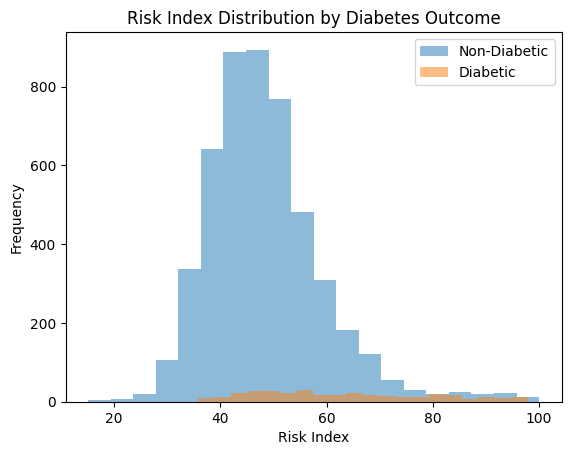

In [ ]:
plt.figure()

plt.hist(df[df['diabetic'] == 0]['RiskIndex'], bins=20, alpha=0.5, label='Non-Diabetic')
plt.hist(df[df['diabetic'] == 1]['RiskIndex'], bins=20, alpha=0.5, label='Diabetic')

plt.title('Risk Index Distribution by Diabetes Outcome')
plt.xlabel('Risk Index')
plt.ylabel('Frequency')
plt.legend()

plt.show()